In [2]:
%%capture

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def my_render_frozen_lake(self):
    original = False  # original frozen lake letter

    if self.lastaction is not None:
        print(f"  ({['Left', 'Down', 'Right', 'Up'][self.lastaction]})")
    else:
        print("")

    desc = self.desc.tolist()

    row, col = self.s // self.ncol, self.s % self.ncol
    desc = [[c.decode("utf-8") for c in line] for line in desc]

    for i, line in enumerate(desc):
        for j, c in enumerate(line):
            if (i, j) == (row, col):
                #print("P", end="")
                print("🧑", end="")
            elif desc[i][j] == "G":
                #print("G", end="")
                print("⛳️", end="")
            elif desc[i][j] == "H":
                #print("H" if original else "O", end="")
                print("🕳", end="")
            else:
                #print("F" if original else ".", end="")
                print("🧊", end="")
        print()


def fix_frozen_lake_render(env):
    # env.render = type(env.render)(my_render_frozen_lake, env)
    unwrapped_env = env.unwrapped
    env.render = type(env.render)(my_render_frozen_lake, unwrapped_env)


## Ambientes de RL
<!-- video shot="/0Ml-ccrTVS4" start="03:50" end="15:07" -->

## O que é um ambiente de aprendizado por reforço (RL environment)?

- Um ambiente de Aprendizado por Reforço pode ser:
  - um jogo, como um video game.
  - uma simulação de um cenário do munod real, como um robô, comportamento do usuário ou do mercado de ações
  - qualquer problema onde um _agente_ que conseuge obter ações (_actions_), visualizar as observações (_observations_), e receber recompensas (_rewards_)
  

O framework Gym (hoje [Gymnasium](https://gymnasium.farama.org/))  trouxe uma interface bem definida para criação de ambientes para aprendizado por reforço.

## Usando o Frozen Lake

Como exemplo de execução de ambiente, usaremos o ambiente [Frozen Lake](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) do [Gymnasium](https://gymnasium.farama.org), que fornece a interface padrão para problemas de RL. Podemos visualizar o ambiente assim:

In [4]:
import gymnasium as gym
env = gym.make("FrozenLake-v1", is_slippery=False)

In [5]:
# HIDDEN
fix_frozen_lake_render(env)

In [6]:
env.reset()
env.render()


🧑🧊🧊🧊
🧊🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️


O objetivo é que o jogador (`P` ou 🧑) alcance a meta (`G` ou ⛳️) caminhando sobre os segmentos congelados do lago (`.` ou 🧊) sem cair nos buracos (`O` ou 🕳).

**Nota**: a renderização do ambiente foi alterada da renderização do Gymnasium para que possa ser exibida claramente nesta plataforma de aprendizagem interativa.

## Movimento

O jogador (agente) pode se mover pelo Frozen Lake (lago congelado). Por exemplo:


In [7]:
env.step(1) # 1 -> Down
env.render()

  (Down)
🧊🧊🧊🧊
🧑🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️


Não se preocupe com o `step(1)` por enquanto; chegaremos a isso.

O que você pode ver é que o jogador (🧑) se moveu para baixo.

## Objetivo

Avance vários passos (steps) e você completou o quebra-cabeça:


In [8]:
env.step(1)
env.step(2)
env.step(1)
env.step(2)
env.step(1)
env.step(2)
env.render()

  (Right)
🧊🧊🧊🧊
🧊🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊🧑


Você alcançou o objetivo alcançando o canto inferior direito.

#### O que torna um ambiente?

Um ambiente envolve vários componentes principais, que abordaremos a seguir.

## Estados

- Usaremos o termo estado (_state_) informalmente para nos referirmos a tudo sobre o meio ambiente.


In [9]:
env.reset()
env.render()


🧑🧊🧊🧊
🧊🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️


- Por exemplo, este é o estado inicial do ambiente.
- O jogador está no canto superior esquerdo, há gelo congelado por perto, etc.
- Usaremos o conceito de estado para falar do nosso ambiente, mas ele não aparecerá na "API".

#### Ações
- Aqui o agente pode escolher entre 4 ações possíveis: esquerda, baixo, direita, cima
- O espaço de todas as ações possíveis é chamado de **espaço de ação**.
- No aprendizagem supervisionada há a distrinção entre regressão ($y$ contínua) e classificação ($y$ categórica)
- Da mesma forma em RL o espaço de ação pode ser contínuo ou discreto
- Neste caso é discreto (4 possibilidades)

O código apresenta essa informação:


In [10]:
env.action_space

Discrete(4)

#### Observações

- As observações são as "partes do estado que o agente pode ver".
- Às vezes, o agente consegue ver tudo; chamamos isso de _totalmente observável_.
- Muitas vezes, temos ambientes _parcialmente observáveis_.
- No exemplo do Frozen Lake, o agente só pode ver a sua própria localização entre os 16 quadrados.
- O agente não é "informado" sobre onde estão os buracos por meio de observações diretas, então ele precisará _aprender_ isso por tentativa e erro.

- O espaço de todas as observações possíveis é chamado de **espaço de observação**.
- Você pode pensar no espaço de ação como análogo ao target (alvo) na aprendizagem supervisionada.
- Você pode pensar no espaço de observação como análogo as *features* da aprendizagem supervisionada.

Aqui, temos um espaço de observação discreto que consiste nas 16 posições possíveis dos jogadores:

In [11]:
env.observation_space

Discrete(16)

## Recompensa

- Na aprendizagem supervisionada, o objetivo geralmente é fazer boas previsões.
- Você ainda pode tentar diferentes funções de perda dependendo do seu objetivo específico, mas o conceito geral é o mesmo.
- Na RL o objetivo pode ser qualquer coisa.
- Mas, como na aprendizagem supervisionada, você precisará _otimizar_ alguma coisa.
- Na RL, pretendemos maximizar a **recompensa** (_reward_).


No exemplo do Frozen Lake, o agente recebe uma recompensa quando atinge a meta.

In [12]:
env.reset()
obs, reward, done, truncated, _  = env.step(0)
env.render()
print("reward =", reward)

  (Left)
🧑🧊🧊🧊
🧊🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️
reward = 0


In [16]:
truncated

False

Vamos descer (_down_):

In [17]:
obs, reward, done, truncated,  _ = env.step(1)
env.render()
print("reward =", reward)

  (Down)
🧊🧊🧊🧊
🧑🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️
reward = 0


4

Ainda sem recompensa, vamos continuar...


In [19]:
env.step(1)
env.step(2)
env.step(1)
env.step(2)
env.step(1)
obs, reward, done, truncated, _ = env.step(2)
env.render()
print("reward =", reward)

  (Right)
🧊🧊🧊🧊
🧊🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊🧑
reward = 1


In [20]:
done

True

Recebemos uma recompensa de 1.0 por atingir a meta.


#### Interação entre Ambiente-Agente

Observe como o agente (neste caso, nós) e o ambiente se comunicam em um ciclo de ida e volta:

![](img/RL-loop.png)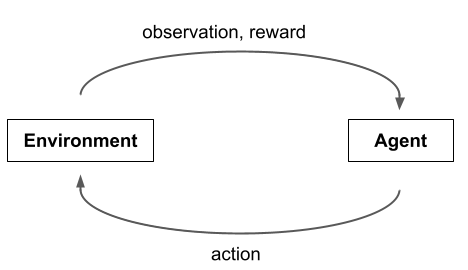

Este é o diagrama clássico que você verá em todos os lugares.

O objetivo será aprender automaticamente o comportamento do agente (fique atento!).

#### Representando ações

- Para usar o RL, precisaremos de uma representação numérica do nosso espaço de ação e do nosso espaço de observação.
- Neste caso, temos 4 ações discretas possíveis, então podemos codificá-las como {0,1,2,3} para (esquerda, baixo, direita, cima) ou (left, down, right, up).
- É por isso que, anteriormente, fizemos

In [24]:
env.step(1)

(15, 0, True, False, {'prob': 1.0})

andar para baixo.

## Representando as observações

- Da mesma forma, precisaremos de uma representação numérica das nossas observações.
- Aqui existem 16 posições possíveis do jogador. Eles são codificados de 0 a 15 da seguinte forma:

```
 0   1   2   3
 4   5   6   7
 8   9  10  11
12  13  14  15
```

Esses detalhes do ambiente Frozen Lake também estão disponíveis na [documentação](https://gymnasium.farama.org/environments/toy_text/frozen_lake/).

Inicialmente, observamos “0” porque começamos no canto superior esquerdo:

In [25]:
env.reset()
env.render()


🧑🧊🧊🧊
🧊🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️


Depois de passar para baixo (ação 1), passamos para a posição 4.

In [26]:
obs, reward, done, truncated, _ = env.step(1)
obs

4

In [27]:
env.render()

  (Down)
🧊🧊🧊🧊
🧑🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️


In [17]:
done

False

A observação é retornada pelo método `step()`.

#### Non-deterministic environments

- Até agora, a execução de uma determinada acção a partir de um determinado estado resultava sempre no mesmo novo estado.
- Em outras palavras, nosso ambiente Frozen Lake era _determinístico_.
- Alguns ambientes são _não determinísticos_, o que significa que o resultado de uma ação pode ser aleatório.
- Podemos inicializar um Frozen Lake não determinístico assim:

In [28]:
env_slippery = gym.make("FrozenLake-v1", is_slippery=True)

In [29]:
env_slippery

<TimeLimit<OrderEnforcing<PassiveEnvChecker<FrozenLakeEnv<FrozenLake-v1>>>>>

In [30]:
# HIDDEN
fix_frozen_lake_render(env_slippery)

In [31]:
env_slippery.reset(seed=4)
env_slippery.render()


🧑🧊🧊🧊
🧊🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️


## Ambientes não determinísticos

In [32]:
env_slippery.step(1) # move down
env_slippery.render()

  (Down)
🧊🧊🧊🧊
🧑🕳🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️


In [33]:
env_slippery.step(1) # move down
env_slippery.render()

  (Down)
🧊🧊🧊🧊
🧊🧑🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️


A descida não funcionou como planejado.

## Ambientes não determinísticos
- No "slippery" Frozen Lake , o movimento só funciona conforme planejado 1/3 do tempo.
  - 1/3 chance da direção pretendida
  - 1/3 acaso cada uma das direções ortogonais
  - 0 chance de se mover na direção oposta à pretendida

- No entanto, _nada disso é do conhecimento do agente; deve aprender com a experiência_.

## Episódios

- O Frozen Lake tem um fim - ou você cai em um buraco ou atinge o objetivo.
- No entanto, uma execução não é suficiente para um algoritmo RL aprender.
- Serão necessários vários interações, chamados **episódio**.
- Após um episódio, o ambiente é redefinido (_reset_).


O `step()` método retorna um sinalizador informando se o episódio acabou:

In [35]:
obs, reward, done, truncated, _ = env_slippery.step(1)
done

True

In [36]:
reward

0

In [37]:
env_slippery.render()

  (Down)
🧊🧊🧊🧊
🧊🧑🧊🕳
🧊🧊🧊🕳
🕳🧊🧊⛳️


Aqui o episódio acabou porque caímos em um buraco.

- Em alguns ambientes (como Frozen Lake), as recompensas só são recebidas no final do episódio.
- Em outros ambientes, as recompensas podem ser recebidas a qualquer **time step** (ou seja, após uma ação).

#### Juntando tudo

- Já falamos sobre os principais componentes de um ambiente RL:
- Estados
- Ações
- Observações
- Recompensas
- Episódios


## Datasets x Ambientes

- No aprendizado supervisionado, normalmente você recebe um conjunto de dados.
- Na RL, o ambiente atua como um _gerador de dados_.
  - Quanto mais você atua no ambiente, mais “dados” você gera e mais pode aprender.
- Também é possível fazer RL em um conjunto de dados pré-coletado (chamado _offline RL_).


#### Let's apply what we learned!

## Self-driving car
<!-- multiple choice -->

Você está usando RL para treinar um carro autônomo. A IA do carro usa várias câmeras e sensores como entradas e tem que decidir o ângulo do volante, bem como o ângulo dos pedais do acelerador/freio no chão.

#### O espaço de observação é contínuo ou discreto?

- [ ] Contínuo
- [ ] Discreto |

<details>
<summary>Clique para dicas</summary>
Neste caso, as observações são as entradas do sensor, por ex. estimativas de profundidade.
</details>


#### O espaço de ação é contínuo ou discreto?

- [ ] Contínuo
- [ ] Discreto

<details>
<summary>Clique para dicas</summary>
As ações são ângulos; eles não vêm de um conjunto discreto de opções.
</details>


#### Qual seria a estrutura de recompensa mais razoável para este ambiente?

- [ ] A recompensa é igual à quantidade de tempo que o carro conseguiu dirigir sem bater |
- [ ] A recompensa é igual à distância que o carro conseguiu percorrer sem bater
- [ ] +1 de recompensa toda vez que o carro bate

<details>
<summary>Clique para dicas</summary>
Opção 1 - Qual seria a recompensa se o carro nunca se movesse?
Opção 3 - Tenha em mente que queremos maximizar a recompensa, não minimizá-la.
</details>

## Episódios vs. time steps
<!-- multiple choice -->

Preencha os espaços em branco na seguinte frase:

*Em um ambiente de aprendizagem por reforço, ações são executadas repetidamente até que o \_\_\_\_\_ termina. Isto pode envolver apenas um \_\_\_\_\_, ou muitos.*

- [ ] time step / recompensa
- [ ] recompensa / time step
- [ ] time step / episódio
- [ ] episódio / time step


## Observations vs. renderings
<!-- coding exercise -->

O ambiente Frozen Lake nos permite criar uma representação visual do ambiente, que vimos anteriormente. Isso é para fins humanos/de depuração e _não_ é visto pelo agente/algoritmo. Sua tarefa aqui é jogar um determinado ambiente de Frozen Lake **sem olhar para a renderização visual** (sem trapaça!). Preencha a lista de `ações` para conter um conjunto de ações que levem corretamente o agente ao objetivo. O que você está experimentando é o que um algoritmo RL “vê” ao aprender!

Observe que o ambiente Frozen Lake fornecido é 3x3 em vez de 4x4. Assim, o espaço de observação vai de 0 a 8 em vez de 0 a 15.

Substitua ____ por uma lista 4 ações.

```python
actions = [____]
for action in actions:
    obs, reward, done, _ = env.step(action)
    print("Obs:", obs, "Reward:", reward, "Done:", done)
```

In [27]:
# EXERCISE

import gymnasium as gym
import numpy as np
np.random.seed(1)
env = gym.make("FrozenLake-v1",
               desc=gym.envs.toy_text.frozen_lake.generate_random_map(size=3, p=0.3, seed = 1),
               is_slippery=False)
env.render = None

obs = env.reset()
#0: Move left
#1: Move down
#2: Move right
#3: Move up
#insera suas ações aqui

actions = [_______]
for action in actions:
    obs, reward, done, truncated, _ = env.step(action)
    print("Obs:", obs, "Reward:", reward, "Done:", done)


NameError: name '_______' is not defined

In [ ]:
import numpy as np
import gymnasium.envs.toy_text
np.random.seed(1)
env = gym.make("FrozenLake-v1", desc=gymnasium.envs.toy_text.frozen_lake.generate_random_map(size=10, p=0.3, seed=1), is_slippery=False)
env.reset(seed=1)
fix_frozen_lake_render(env)
env.render()

## Melhor caminho para o objetivo

Lembrando que as ações 0, 1, 2, 3 representam esquerda, baixo, direita, cima (respectivamente), qual das afirmações a seguir descreve corretamente o melhor caminho para o objetivo?

- [ ] Comece movendo para baixo e depois para baixo novamente
- [ ] Comece movendo para baixo e depois para a direita
- [ ] Comece movendo para a direita e depois para a direita novamente
- [ ] Comece movendo para a direita e depois para baixo